# PyTorch Introduction for Neuroscience

| Tutorial status | Details |
|---|---|
| **Course role** | Conceptual and visual PyTorch introduction for neuroscience seminars |
| **Expected runtime** | 20-35 minutes |
| **Hardware** | CPU is sufficient; CUDA is optional |
| **External data** | None |
| **Validation** | Designed for sequential execution |


This notebook is the recommended seminar prerequisite. It emphasizes intuition and visualization; use `00_pytorch_basics.ipynb` for exercises and technical practice.

**Goal**: Learn the PyTorch workflow used to build neural encoding, decoding, and generative models.

**Why PyTorch?**
- Tensors make numerical computation concise.
- Automatic differentiation computes gradients for optimization.
- `nn.Module` organizes model parameters and forward passes.
- GPU support is built in when CUDA is available.
- The same workflow scales from GLMs to VAEs and modern neural models.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check PyTorch version and GPU availability
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

sns.set_style('whitegrid')

PyTorch version: 2.4.0
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU


## Part 1: Tensors

### What is a tensor?

A tensor is an array with any number of dimensions. PyTorch uses tensors for model inputs, outputs, parameters, and gradients.

| Name | Dimensions | Example |
|---|---:|---|
| Scalar | 0D | `42` |
| Vector | 1D | `[1, 2, 3, 4]` |
| Matrix | 2D | `[[1, 2], [3, 4]]` |
| Higher-order tensor | 3D or more | A batch of images or a neural time series |

### Key properties

- **Shape** describes the size of every dimension, such as `(batch, features)` or `(batch, channels, height, width)`.
- **Data type** controls how values are represented, such as `torch.float32` or `torch.int64`.
- **Device** determines whether computation runs on the CPU or GPU.
- **Gradient tracking** is enabled with `requires_grad=True` when PyTorch should differentiate operations involving the tensor.


In [2]:
# Creating tensors
print('='*60)
print('Creating Tensors')
print('='*60)

# From Python lists
x = torch.tensor([1.0, 2.0, 3.0])
print(f'\nFrom list: {x}')
print(f'  Shape: {x.shape}')
print(f'  Data type: {x.dtype}')

# Random tensors
x_random = torch.randn(3, 4)  # Normal distribution
print(f'\nRandom (34): shape={x_random.shape}')
print(x_random)

# Zeros and ones
zeros = torch.zeros(2, 3)
ones = torch.ones(2, 3)
print(f'\nZeros shape: {zeros.shape}')
print(f'Ones shape: {ones.shape}')

# From numpy
np_array = np.array([1, 2, 3])
tensor_from_np = torch.from_numpy(np_array)
print(f'\nFrom numpy: {tensor_from_np}')
print(f'  Type: {tensor_from_np.dtype}')

Creating Tensors

From list: tensor([1., 2., 3.])
  Shape: torch.Size([3])
  Data type: torch.float32

Random (34): shape=torch.Size([3, 4])
tensor([[-0.3464, -0.5995, -0.7697, -1.1552],
        [ 3.4208, -1.4389,  1.5623, -0.0932],
        [ 0.0504, -0.6982, -1.3762, -0.0865]])

Zeros shape: torch.Size([2, 3])
Ones shape: torch.Size([2, 3])

From numpy: tensor([1, 2, 3], dtype=torch.int32)
  Type: torch.int32


In [3]:
# Tensor operations
print('\n' + '='*60)
print('Tensor Operations')
print('='*60)

a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

# Element-wise operations
print(f'\na + b = {a + b}')
print(f'a - b = {a - b}')
print(f'a * b = {a * b}')  # Element-wise multiplication
print(f'a / b = {a / b}')

# Matrix multiplication
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])
print(f'\nA @ B (matrix multiply) =')
print(A @ B)

# Reshaping
x = torch.arange(12).float()
print(f'\nOriginal shape: {x.shape}')
x_reshaped = x.reshape(3, 4)
print(f'Reshaped to (3,4): {x_reshaped.shape}')

# Indexing
print(f'\nFirst element: {x[0]}')
print(f'First three: {x[:3]}')
print(f'Element [1,2]: {x_reshaped[1, 2]}')


Tensor Operations

a + b = tensor([5., 7., 9.])
a - b = tensor([-3., -3., -3.])
a * b = tensor([ 4., 10., 18.])
a / b = tensor([0.2500, 0.4000, 0.5000])

A @ B (matrix multiply) =
tensor([[19., 22.],
        [43., 50.]])

Original shape: torch.Size([12])
Reshaped to (3,4): torch.Size([3, 4])

First element: 0.0
First three: tensor([0., 1., 2.])
Element [1,2]: 6.0


### Visualization: Tensor Values and Matrix Multiplication

Heatmaps are often the fastest way to inspect tensor structure. Here we visualize a random tensor and the matrices used in the matrix multiplication example.


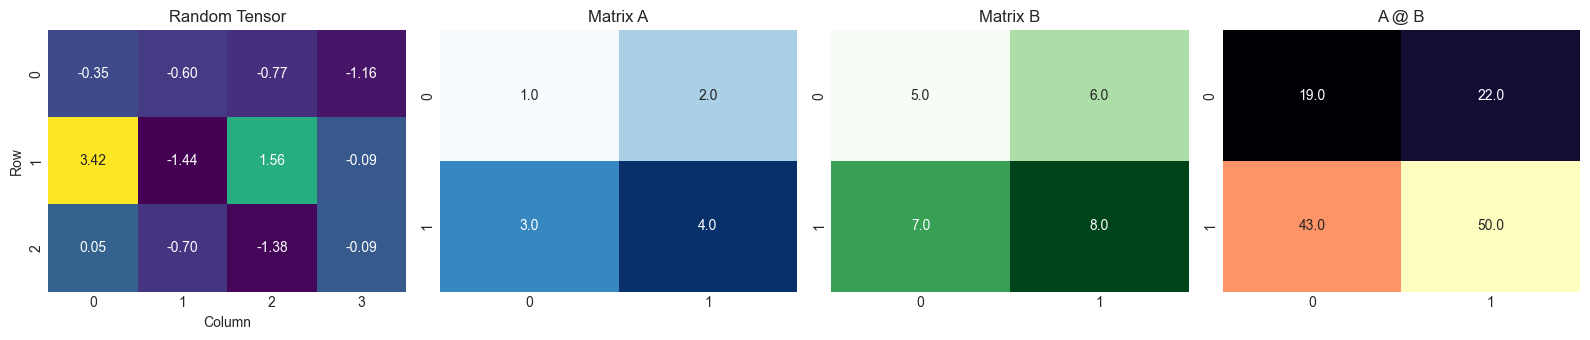

In [4]:
# Visualize tensor values and matrix multiplication
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

sns.heatmap(x_random.numpy(), annot=True, fmt='.2f', cmap='viridis', ax=axes[0], cbar=False)
axes[0].set_title('Random Tensor')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Row')

sns.heatmap(A.numpy(), annot=True, fmt='.1f', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Matrix A')

sns.heatmap(B.numpy(), annot=True, fmt='.1f', cmap='Greens', ax=axes[2], cbar=False)
axes[2].set_title('Matrix B')

product = A @ B
sns.heatmap(product.numpy(), annot=True, fmt='.1f', cmap='magma', ax=axes[3], cbar=False)
axes[3].set_title('A @ B')

for ax in axes:
    ax.tick_params(axis='both', length=0)

plt.tight_layout()
plt.show()


## Part 2: Automatic Differentiation

### From prediction to parameter update

1. **Forward pass:** the model maps an input $x$ to a prediction $\hat{y}$.
2. **Loss:** $L(\hat{y}, y)$ measures the difference between the prediction and target.
3. **Backward pass:** PyTorch computes $\partial L/\partial \theta$ for each trainable parameter $\theta$.
4. **Update:** the optimizer changes the parameters to reduce the loss:

$$
\theta \leftarrow \theta - \eta \frac{\partial L}{\partial \theta}.
$$

### PyTorch autograd

Set `requires_grad=True` on a tensor that needs gradients. PyTorch then records the operations involving that tensor and builds a computation graph. Calling `loss.backward()` applies backpropagation to populate the `.grad` field of each parameter.


### Core Concepts: Gradient, Loss, and Backpropagation

#### What is a derivative?

A derivative measures how quickly one quantity changes when another quantity changes. For a one-dimensional function $y=f(x)$, the derivative

$$
\frac{dy}{dx}
$$

is the local slope of the function. For example, if $y=x^2$, then $dy/dx=2x$. At $x=3$, the slope is $6$: a small increase in $x$ produces an approximately six-times-larger increase in $y$.

#### What is a gradient?

A neural network has many parameters, collected in a vector $\theta$. The gradient of a loss $L$ is the vector of partial derivatives

$$
\nabla_\theta L = \left[\frac{\partial L}{\partial \theta_1}, \ldots, \frac{\partial L}{\partial \theta_n}\right].
$$

Each component answers: "If this parameter increases slightly, how will the loss change?" The gradient points toward the steepest increase in loss, so training moves in the opposite direction.

#### Loss, backpropagation, and optimization

- **Prediction**: the network maps an input $x$ to a prediction $\hat{y}$.
- **Loss function**: a scalar score measures the difference between $\hat{y}$ and the target $y$. Smaller is better.
- **Backpropagation**: the chain rule passes information backward through the computation graph and computes the gradient for every trainable parameter.
- **Learning rate**: $\eta$ controls the size of each parameter update.
- **Optimizer**: SGD, Adam, and related algorithms use gradients to update parameters.

The basic gradient-descent update is

$$
\theta \leftarrow \theta - \eta \nabla_\theta L.
$$

A learning rate that is too small makes training slow; one that is too large can overshoot the minimum or make training unstable.


In [5]:
print('\n' + '='*60)
print('Automatic Differentiation')
print('='*60)

# Simple example: y = x^2
x = torch.tensor(3.0, requires_grad=True)
print(f'\nInitial: x = {x.item()}')

# Forward pass
y = x ** 2
print(f'Forward: y = x^2 = {y.item()}')

# Backward pass (compute gradient)
y.backward()
print(f'\nAfter backward:')
print(f'  dy/dx = {x.grad.item()} (should be 2*x = 6)')

# More complex example
print('\n' + '-'*60)
print('Complex Function: z = (x + 2y)^2')

x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

# Forward pass
z = (x + 2*y) ** 2
print(f'z = {z.item()}')

# Backward
z.backward()
print(f'\nGradients:')
print(f'  dz/dx = {x.grad.item()} (should be 2*(x+2y) = 10)')
print(f'  dz/dy = {y.grad.item()} (should be 4*(x+2y) = 20)')


Automatic Differentiation

Initial: x = 3.0
Forward: y = x^2 = 9.0

After backward:
  dy/dx = 6.0 (should be 2*x = 6)

------------------------------------------------------------
Complex Function: z = (x + 2y)^2
z = 25.0

Gradients:
  dz/dx = 10.0 (should be 2*(x+2y) = 10)
  dz/dy = 20.0 (should be 4*(x+2y) = 20)


### Visualization: Function Shape and Local Gradient

The derivative is the local slope of a function. Autograd computes this slope exactly for the operations PyTorch tracked.


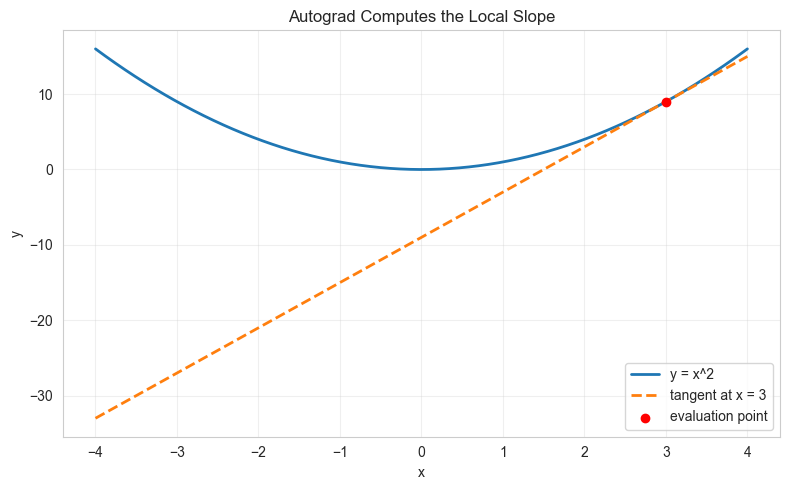

In [6]:
# Visualize y = x^2 and the tangent line at x = 3
x_grid = torch.linspace(-4, 4, 200)
y_grid = x_grid ** 2
x0 = 3.0
y0 = x0 ** 2
slope = 2 * x0
tangent = y0 + slope * (x_grid - x0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_grid.numpy(), y_grid.numpy(), label='y = x^2', linewidth=2)
ax.plot(x_grid.numpy(), tangent.numpy(), '--', label='tangent at x = 3', linewidth=2)
ax.scatter([x0], [y0], color='red', zorder=3, label='evaluation point')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Autograd Computes the Local Slope')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Visualization: Gradient Descent

The example below treats $\theta$ as a single model parameter. At each step, the gradient gives the local slope of the loss curve, and the update moves $\theta$ in the opposite direction. Real neural networks apply the same idea to thousands or millions of parameters at once.


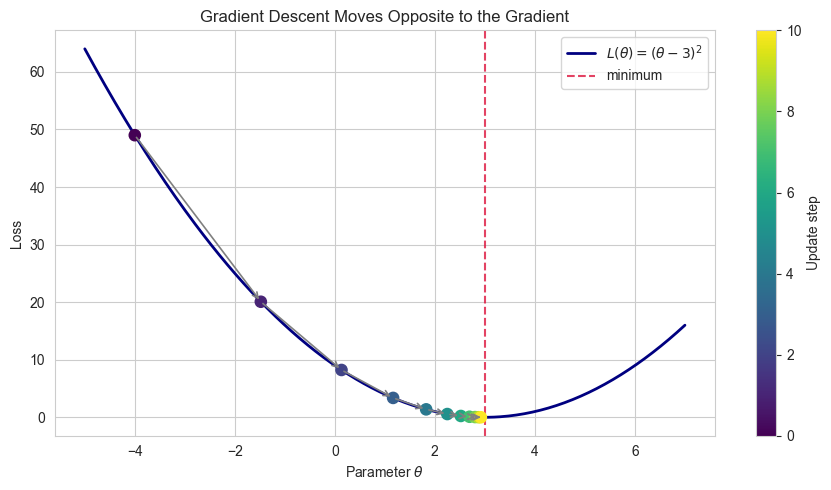

In [7]:
# Visualize gradient descent on a one-parameter loss function
theta_grid = torch.linspace(-5, 7, 300)
loss_grid = (theta_grid - 3) ** 2

theta = torch.tensor(-4.0)
learning_rate = 0.18
trajectory = [theta.item()]

for _ in range(10):
    gradient = 2 * (theta - 3)
    theta = theta - learning_rate * gradient
    trajectory.append(theta.item())

trajectory = np.array(trajectory)
trajectory_loss = (trajectory - 3) ** 2

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(theta_grid.numpy(), loss_grid.numpy(), color='navy', linewidth=2,
        label=r'$L(\theta)=(\theta-3)^2$')
points = ax.scatter(trajectory, trajectory_loss, c=np.arange(len(trajectory)),
                    cmap='viridis', s=65, zorder=3)
for start, end in zip(range(len(trajectory) - 1), range(1, len(trajectory))):
    ax.annotate('', xy=(trajectory[end], trajectory_loss[end]),
                xytext=(trajectory[start], trajectory_loss[start]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

ax.axvline(3, color='crimson', linestyle='--', alpha=0.8, label='minimum')
ax.set_xlabel(r'Parameter $\theta$')
ax.set_ylabel('Loss')
ax.set_title('Gradient Descent Moves Opposite to the Gradient')
ax.legend()
fig.colorbar(points, ax=ax, label='Update step')
plt.tight_layout()
plt.show()


In [8]:
# Gradient computation for neural networks
print('\n' + '='*60)
print('Gradients for Model Parameters')
print('='*60)

# Simple model: y = w*x + b
torch.manual_seed(42)
x_data = torch.randn(10, 1)  # 10 samples
y_data = 3*x_data + 2 + torch.randn(10, 1) * 0.1  # y = 3x + 2 + noise

# Model parameters
w = torch.tensor(0.5, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# Forward pass
y_pred = w * x_data + b

# Loss (Mean Squared Error)
loss = ((y_pred - y_data) ** 2).mean()
print(f'Loss = {loss.item():.4f}')

# Backward
loss.backward()
print(f'\nGradients after backward:')
print(f'  dL/dw = {w.grad.item():.4f}')
print(f'  dL/db = {b.grad.item():.4f}')

# Manual gradient check
print(f'\nTrue parameters: w=3, b=2')
print(f'Learned parameters: w={w.item():.2f}, b={b.item():.2f}')
print(f'Gradients point toward better solution')


Gradients for Model Parameters
Loss = 10.5700

Gradients after backward:
  dL/dw = -4.3774
  dL/db = -4.9873

True parameters: w=3, b=2
Learned parameters: w=0.50, b=0.00
Gradients point toward better solution


## Part 3: Neural Network Modules

### Building blocks

| Module | Role | Operation |
|---|---|---|
| `nn.Linear(in_features, out_features)` | Learn a weighted combination of inputs | $y=Wx+b$ |
| `nn.ReLU()` | Add nonlinearity | $\operatorname{ReLU}(x)=\max(0,x)$ |
| `nn.Sigmoid()` | Map values to the interval $(0,1)$ | $\sigma(x)=1/(1+e^{-x})$ |
| `nn.Tanh()` | Map values to the interval $(-1,1)$ | $\tanh(x)$ |

### Creating a model

An `nn.Module` stores trainable parameters and defines how data moves through the network in its `forward` method.

```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(10, 64)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x
```


In [9]:
print('\n' + '='*60)
print('Neural Network Modules')
print('='*60)

# Define a simple network
class SimpleNet(nn.Module):
    def __init__(self, input_size=10, hidden_size=64, output_size=1):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x

# Create model
model = SimpleNet()
print(f'\nModel:')
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params}')

# Forward pass
x_test = torch.randn(5, 10)  # Batch of 5 samples
y_test = model(x_test)
print(f'\nInput shape: {x_test.shape}')
print(f'Output shape: {y_test.shape}')
print(f'First output: {y_test[0].item():.4f}')


Neural Network Modules

Model:
SimpleNet(
  (linear1): Linear(in_features=10, out_features=64, bias=True)
  (relu): ReLU()
  (linear2): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 769

Input shape: torch.Size([5, 10])
Output shape: torch.Size([5, 1])
First output: -0.2423


### Visualization: Neural Network Architecture

`SimpleNet` is a feedforward neural network:

1. The input layer receives 10 features for each sample.
2. `Linear(10, 64)` computes 64 weighted sums plus biases.
3. `ReLU` replaces negative hidden activations with zero, allowing the network to model nonlinear relationships.
4. `Linear(64, 1)` combines the hidden features into one output.

During the **forward pass**, information moves from input to prediction. During the **backward pass**, gradients move from the loss toward earlier layers. The arrows in the diagram show these two directions; the drawing uses representative circles rather than displaying all 64 hidden units.


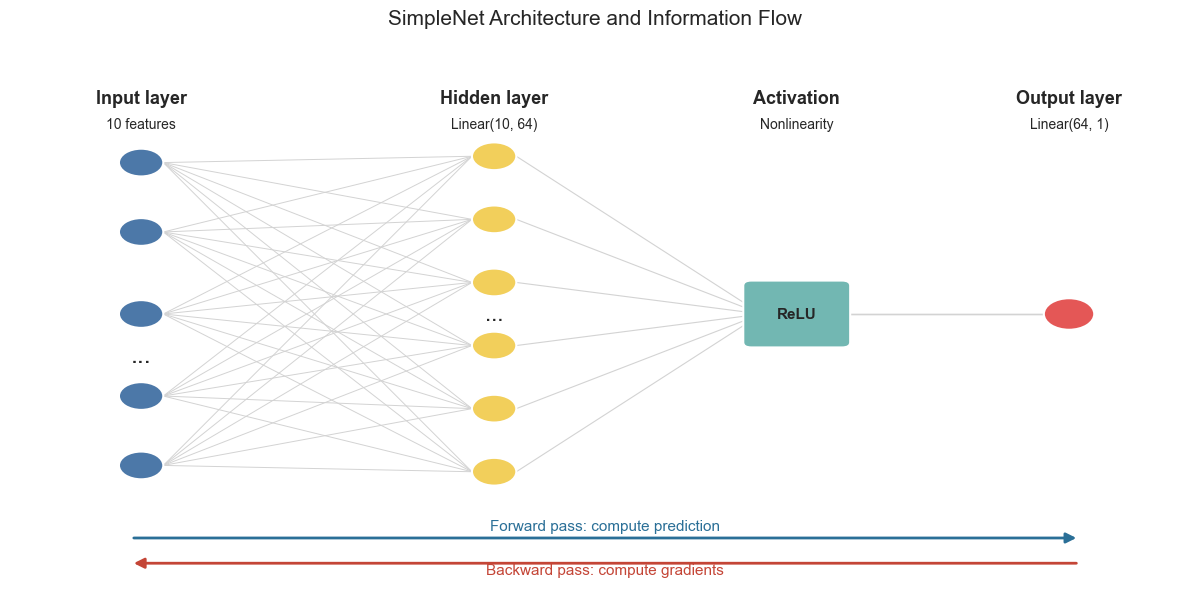

In [10]:
# Draw the architecture of SimpleNet
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(-0.8, 10.8)
ax.set_ylim(-1.2, 7.2)
ax.axis('off')

layer_x = [0.5, 4.0, 7.0, 9.7]
input_y = [0.6, 1.7, 3.0, 4.3, 5.4]
hidden_y = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
output_y = [3.0]

# Connections are intentionally light so the layer structure remains readable.
for y_in in input_y:
    for y_hidden in hidden_y:
        ax.plot([layer_x[0] + 0.22, layer_x[1] - 0.22], [y_in, y_hidden],
                color='lightgray', linewidth=0.7, zorder=0)
for y_hidden in hidden_y:
    ax.plot([layer_x[1] + 0.22, layer_x[2] - 0.35], [y_hidden, 3.0],
            color='lightgray', linewidth=0.8, zorder=0)
    ax.plot([layer_x[2] + 0.35, layer_x[3] - 0.22], [3.0, 3.0],
            color='lightgray', linewidth=0.8, zorder=0)

for y in input_y:
    ax.add_patch(Circle((layer_x[0], y), 0.22, facecolor='#4C78A8',
                        edgecolor='white', linewidth=1.5, zorder=2))
for y in hidden_y:
    ax.add_patch(Circle((layer_x[1], y), 0.22, facecolor='#F2CF5B',
                        edgecolor='white', linewidth=1.5, zorder=2))

relu_box = FancyBboxPatch((layer_x[2] - 0.45, 2.55), 0.9, 0.9,
                          boxstyle='round,pad=0.08', facecolor='#72B7B2',
                          edgecolor='white', linewidth=1.5, zorder=2)
ax.add_patch(relu_box)
ax.text(layer_x[2], 3.0, 'ReLU', ha='center', va='center',
        fontsize=11, weight='bold')
ax.add_patch(Circle((layer_x[3], output_y[0]), 0.25, facecolor='#E45756',
                    edgecolor='white', linewidth=1.5, zorder=2))

ax.text(layer_x[0], 6.35, 'Input layer', ha='center', fontsize=13, weight='bold')
ax.text(layer_x[0], 5.95, '10 features', ha='center', fontsize=10)
ax.text(layer_x[1], 6.35, 'Hidden layer', ha='center', fontsize=13, weight='bold')
ax.text(layer_x[1], 5.95, 'Linear(10, 64)', ha='center', fontsize=10)
ax.text(layer_x[2], 6.35, 'Activation', ha='center', fontsize=13, weight='bold')
ax.text(layer_x[2], 5.95, 'Nonlinearity', ha='center', fontsize=10)
ax.text(layer_x[3], 6.35, 'Output layer', ha='center', fontsize=13, weight='bold')
ax.text(layer_x[3], 5.95, 'Linear(64, 1)', ha='center', fontsize=10)
ax.text(layer_x[0], 2.35, '...', ha='center', va='center', fontsize=18)
ax.text(layer_x[1], 3.0, '...', ha='center', va='center', fontsize=16)

forward = FancyArrowPatch((0.4, -0.55), (9.8, -0.55), arrowstyle='-|>',
                          mutation_scale=15, linewidth=2, color='#2A6F97')
backward = FancyArrowPatch((9.8, -0.95), (0.4, -0.95), arrowstyle='-|>',
                           mutation_scale=15, linewidth=2, color='#C44536')
ax.add_patch(forward)
ax.add_patch(backward)
ax.text(5.1, -0.42, 'Forward pass: compute prediction', ha='center',
        color='#2A6F97', fontsize=11)
ax.text(5.1, -1.12, 'Backward pass: compute gradients', ha='center',
        color='#C44536', fontsize=11)
ax.set_title('SimpleNet Architecture and Information Flow', fontsize=15, pad=18)
plt.tight_layout()
plt.show()


### Visualization: Activations Inside a Small Network

A forward pass transforms inputs layer by layer. The histograms below show how the first linear layer and ReLU change activation values.


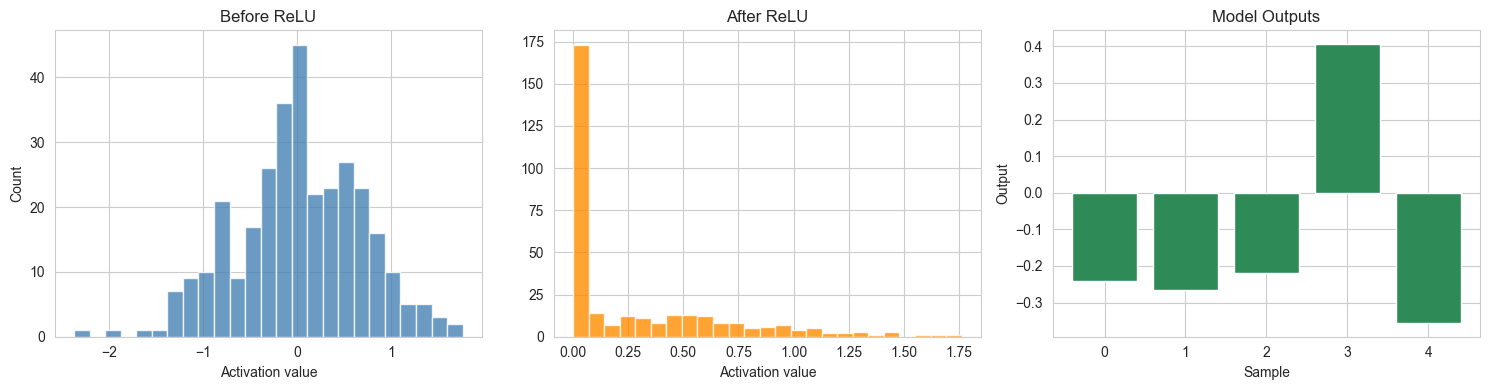

In [11]:
# Visualize hidden activations in the SimpleNet model
with torch.no_grad():
    hidden_pre = model.linear1(x_test)
    hidden_post = model.relu(hidden_pre)
    outputs = model(x_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(hidden_pre.numpy().ravel(), bins=25, color='steelblue', alpha=0.8)
axes[0].set_title('Before ReLU')
axes[0].set_xlabel('Activation value')
axes[0].set_ylabel('Count')

axes[1].hist(hidden_post.numpy().ravel(), bins=25, color='darkorange', alpha=0.8)
axes[1].set_title('After ReLU')
axes[1].set_xlabel('Activation value')

axes[2].bar(np.arange(len(outputs)), outputs.numpy().ravel(), color='seagreen')
axes[2].set_title('Model Outputs')
axes[2].set_xlabel('Sample')
axes[2].set_ylabel('Output')

plt.tight_layout()
plt.show()


## Part 4: Training Loop

### How learning happens

Training repeatedly performs five operations:

1. **Clear old gradients** with `optimizer.zero_grad()`. PyTorch accumulates gradients by default.
2. **Forward pass**: compute predictions from the current parameters.
3. **Loss calculation**: reduce prediction error to one scalar value.
4. **Backward pass**: `loss.backward()` applies the chain rule and fills each parameter's `.grad` field.
5. **Parameter update**: `optimizer.step()` changes the parameters using those gradients.

```python
for epoch in range(num_epochs):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred, y_true)
    loss.backward()
    optimizer.step()
```

An **epoch** is one complete pass through the training data. A **batch** is the subset of samples processed before one parameter update. The loss curve helps diagnose whether training is converging, learning too slowly, or becoming unstable.


In [12]:
print('\n' + '='*60)
print('Training Loop Example')
print('='*60)

# Generate synthetic regression data
torch.manual_seed(42)
X_train = torch.randn(100, 10)
# True relationship: y = sum of first 3 features + noise
y_train = (X_train[:, 0] + 2*X_train[:, 1] - X_train[:, 2] + torch.randn(100) * 0.1).unsqueeze(1)

# Create model, loss, optimizer
model = SimpleNet(input_size=10, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 100
losses = []

for epoch in range(num_epochs):
    # Forward pass
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    
    # Backward pass
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()         # Compute gradients
    optimizer.step()        # Update parameters
    
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}: Loss = {loss.item():.4f}')

print(f'\nFinal loss: {losses[-1]:.4f}')
print(f'Initial loss: {losses[0]:.4f}')
print(f'Improvement: {(losses[0] - losses[-1]) / losses[0] * 100:.1f}%')


Training Loop Example
Epoch  20: Loss = 1.5640
Epoch  40: Loss = 0.2324
Epoch  60: Loss = 0.0539
Epoch  80: Loss = 0.0239
Epoch 100: Loss = 0.0143

Final loss: 0.0143
Initial loss: 7.6637
Improvement: 99.8%


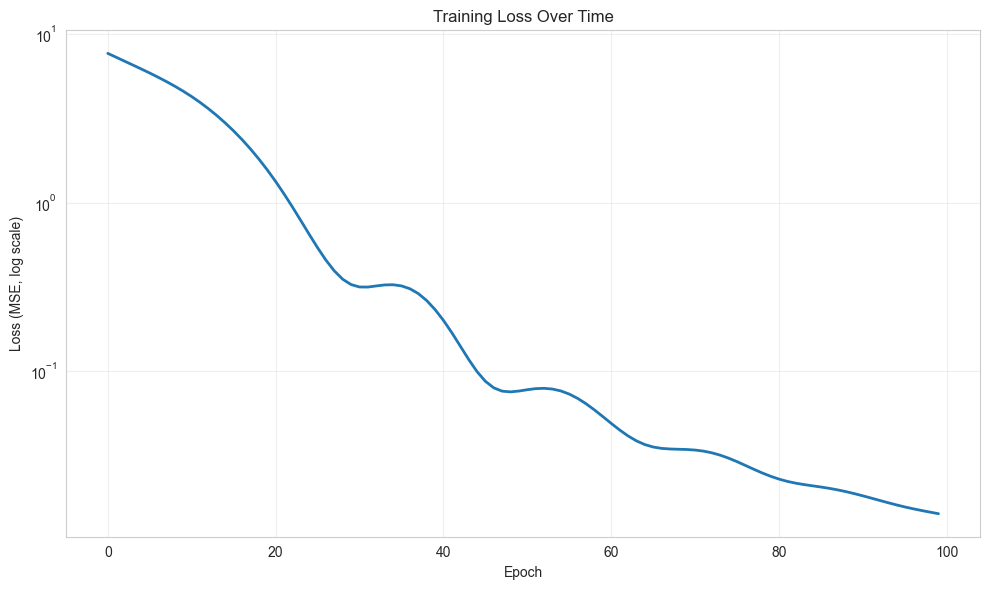

In [13]:
# Visualize training
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(losses, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE, log scale)')
ax.set_title('Training Loss Over Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualization: Predictions and Residuals

A loss curve shows optimization progress, but prediction plots show what the model learned in data space.


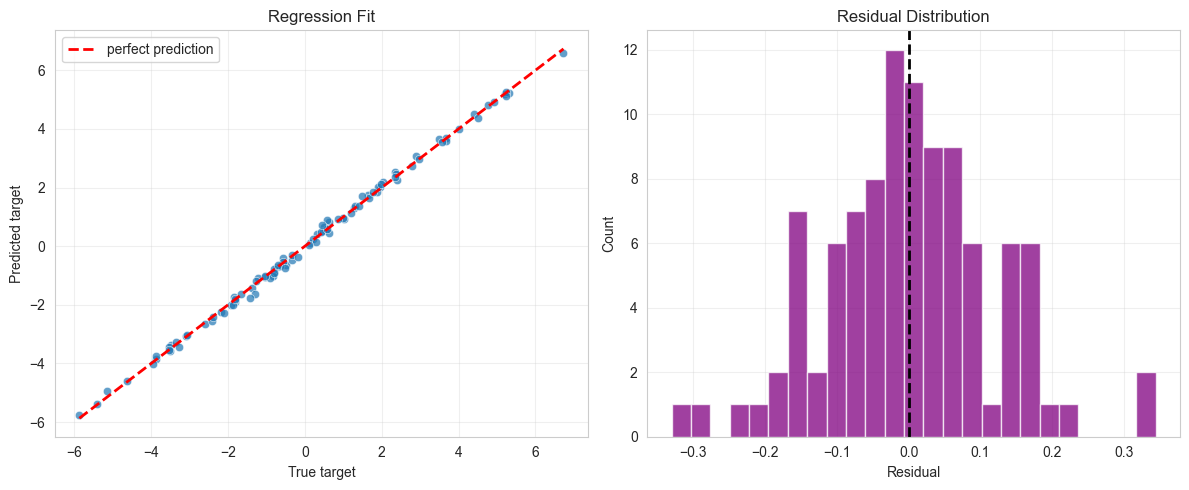

In [14]:
# Visualize fitted predictions and residuals
with torch.no_grad():
    train_pred = model(X_train).squeeze().numpy()
    train_true = y_train.squeeze().numpy()
    residuals = train_true - train_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(train_true, train_pred, alpha=0.7, edgecolor='white', linewidth=0.5)
min_val = min(train_true.min(), train_pred.min())
max_val = max(train_true.max(), train_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='perfect prediction')
axes[0].set_xlabel('True target')
axes[0].set_ylabel('Predicted target')
axes[0].set_title('Regression Fit')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=25, color='purple', alpha=0.75)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Part 5: Application to Neuroscience

### Example: A GLM for neural response prediction

The model predicts a firing rate from stimulus features:

$$
\text{firing rate}=f(\text{stimulus}\,W+b),
$$

where $f$ is a nonlinear function that keeps the firing rate positive. Training minimizes the negative Poisson log likelihood, which is appropriate for spike-count data.

This section simulates stimulus features, generates spike counts from a Poisson model, and fits the GLM in PyTorch.


In [15]:
print('\n' + '='*60)
print('Neural Encoding Example: GLM')
print('='*60)

# Simulate neural data
torch.manual_seed(42)
n_timepoints = 1000
n_features = 50  # Feature dimension of stimulus

# Generate random stimulus
stimulus = torch.randn(n_timepoints, n_features)

# Generate spike counts (Poisson with rate determined by stimulus)
true_weights = torch.randn(n_features, 1) * 0.1
true_bias = torch.tensor(0.5)
true_rate = torch.nn.functional.softplus(stimulus @ true_weights + true_bias)
spike_counts = torch.poisson(true_rate).float()

print(f'\nData shape:')
print(f'  Stimulus: {stimulus.shape}')
print(f'  Spike counts: {spike_counts.shape}')
print(f'  Mean firing rate: {spike_counts.mean().item():.3f}')

# Define GLM model
class GLM(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1, bias=True)
    
    def forward(self, x):
        # Linear prediction
        log_rate = self.linear(x)
        # Exponential nonlinearity to ensure positive rate
        rate = torch.exp(log_rate)
        return rate

# Train GLM
glm = GLM(n_features)
optimizer = optim.Adam(glm.parameters(), lr=0.1)

num_epochs = 200
glm_losses = []

for epoch in range(num_epochs):
    # Forward pass
    rate = glm(stimulus)
    
    # Poisson loss: -log p(data|rate)
    loss = -(spike_counts * torch.log(rate + 1e-8) - rate).mean()
    
    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    glm_losses.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:3d}: Loss = {loss.item():.4f}')

# Compare learned vs true weights
learned_weights = glm.linear.weight.detach().numpy().flatten()
true_weights_np = true_weights.numpy().flatten()

print(f'\nWeight recovery:')
print(f'  Correlation: {np.corrcoef(learned_weights, true_weights_np)[0,1]:.3f}')
print(f'  Learned bias: {glm.linear.bias.item():.3f} (true: {true_bias.item():.3f})')


Neural Encoding Example: GLM

Data shape:
  Stimulus: torch.Size([1000, 50])
  Spike counts: torch.Size([1000, 1])
  Mean firing rate: 1.044
Epoch  50: Loss = 0.9009
Epoch 100: Loss = 0.9002
Epoch 150: Loss = 0.9002
Epoch 200: Loss = 0.9002

Weight recovery:
  Correlation: 0.878
  Learned bias: -0.040 (true: 0.500)


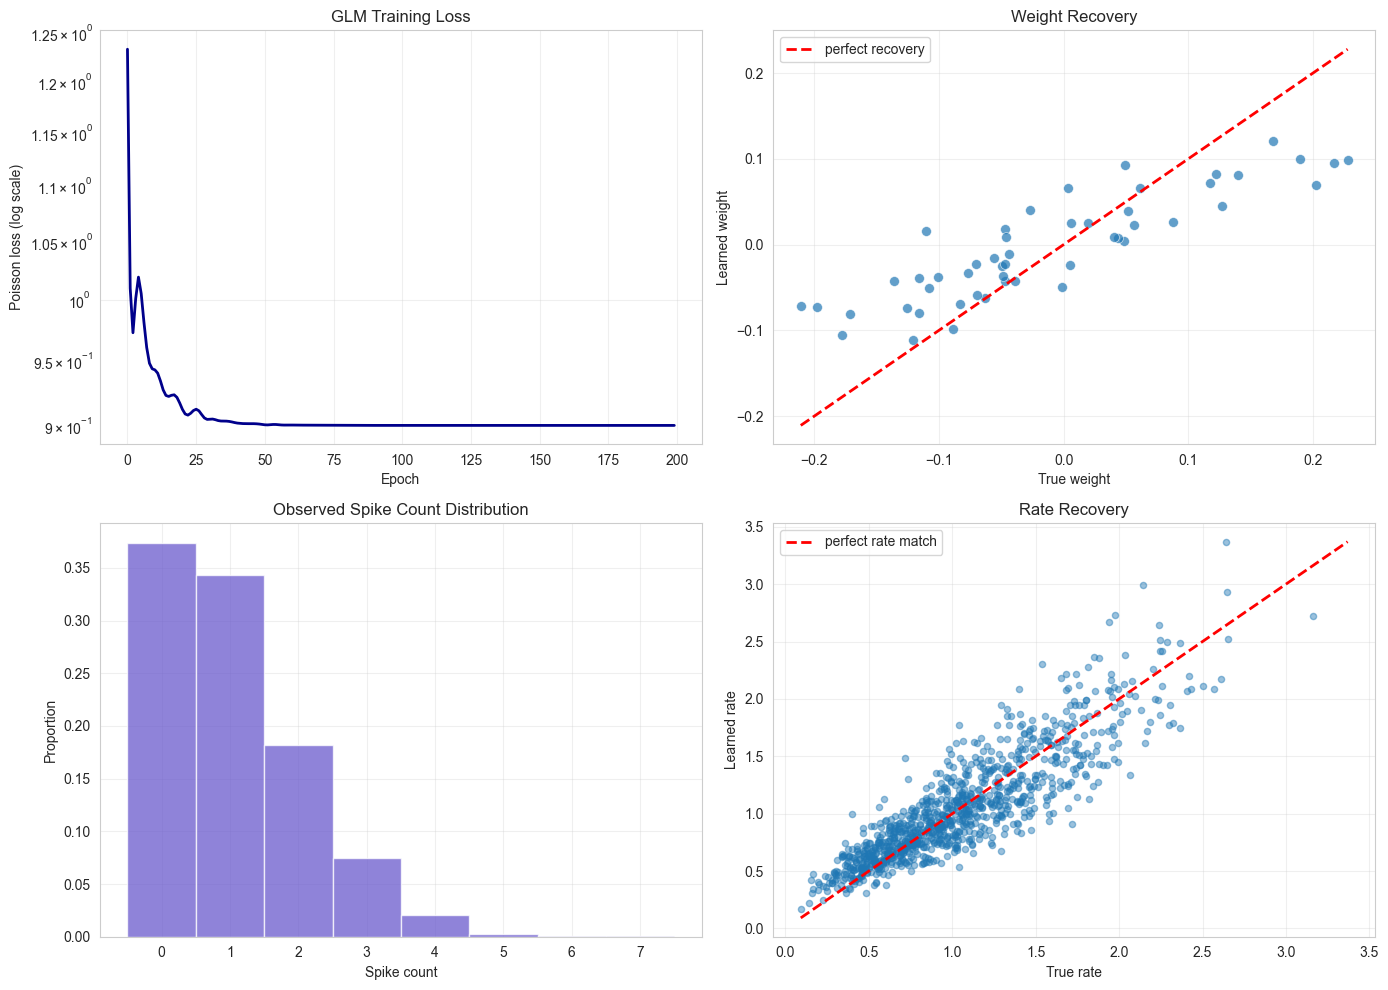

GLM successfully recovered stimulus features and firing-rate structure.


In [16]:
# Visualize GLM training, weights, rates, and spike counts
with torch.no_grad():
    learned_rate = glm(stimulus).squeeze().numpy()
    observed_spikes = spike_counts.squeeze().numpy()
    true_rate_np = true_rate.squeeze().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training loss
ax = axes[0, 0]
ax.semilogy(glm_losses, linewidth=2, color='darkblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Poisson loss (log scale)')
ax.set_title('GLM Training Loss')
ax.grid(True, alpha=0.3)

# Plot 2: Weight recovery
ax = axes[0, 1]
ax.scatter(true_weights_np, learned_weights, alpha=0.7, s=50, edgecolor='white', linewidth=0.5)
weight_min = min(true_weights_np.min(), learned_weights.min())
weight_max = max(true_weights_np.max(), learned_weights.max())
ax.plot([weight_min, weight_max], [weight_min, weight_max], 'r--', linewidth=2, label='perfect recovery')
ax.set_xlabel('True weight')
ax.set_ylabel('Learned weight')
ax.set_title('Weight Recovery')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Observed spike-count distribution
ax = axes[1, 0]
max_count = int(observed_spikes.max())
bins = np.arange(max_count + 2) - 0.5
ax.hist(observed_spikes, bins=bins, density=True, color='slateblue', alpha=0.75, edgecolor='white')
ax.set_xlabel('Spike count')
ax.set_ylabel('Proportion')
ax.set_title('Observed Spike Count Distribution')
ax.grid(True, alpha=0.3)

# Plot 4: Predicted rate versus true generative rate
ax = axes[1, 1]
ax.scatter(true_rate_np, learned_rate, alpha=0.45, s=20)
rate_min = min(true_rate_np.min(), learned_rate.min())
rate_max = max(true_rate_np.max(), learned_rate.max())
ax.plot([rate_min, rate_max], [rate_min, rate_max], 'r--', linewidth=2, label='perfect rate match')
ax.set_xlabel('True rate')
ax.set_ylabel('Learned rate')
ax.set_title('Rate Recovery')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('GLM successfully recovered stimulus features and firing-rate structure.')


## Summary: PyTorch Essentials

### Key concepts

1. **Tensors** are N-dimensional arrays. They can live on a CPU or GPU and can participate in a computation graph.
2. **Autograd** performs automatic differentiation. Enable tracking with `requires_grad=True` and compute gradients with `.backward()`.
3. **Modules** organize model layers and trainable parameters. Common examples include `nn.Linear` and `nn.ReLU`.
4. **Training** alternates between a forward pass, loss calculation, backward pass, and optimizer update.
5. **Applications** include regression, classification, neural encoding models, and generative models such as VAEs.

### Core training commands

| Command | Purpose |
|---|---|
| `optimizer.zero_grad()` | Clear gradients left by the previous update |
| `loss.backward()` | Compute gradients using backpropagation |
| `optimizer.step()` | Update trainable parameters |

### Next: Applied models

These fundamentals support the models introduced in later chapters:

- Generalized linear models for spike prediction
- Bayesian decoding
- Hidden Markov models
- Variational autoencoders
